In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for better aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6) # Default figure size

# --- Load the Cleaned Dataset ---
CLEANED_FILE_NAME = 'cleaned_video_games_data.csv' # Make sure this file is in the same directory!
try:
    df = pd.read_csv(CLEANED_FILE_NAME)
    print(f"Successfully loaded {CLEANED_FILE_NAME}. Shape: {df.shape}")
except FileNotFoundError:
    print(f"ERROR: File '{CLEANED_FILE_NAME}' not found. Please ensure the cleaning script was run and the file exists.")

Successfully loaded cleaned_video_games_data.csv. Shape: (6826, 16)


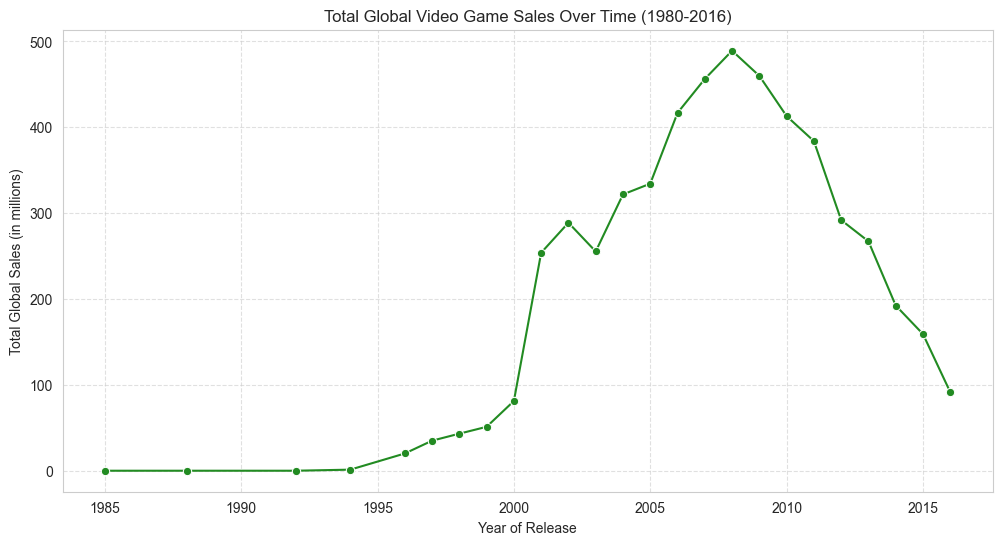

In [2]:
# Group data by year and sum sales for a single line plot
sales_by_year = df.groupby('Year_of_Release')['Global_Sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_by_year, x='Year_of_Release', y='Global_Sales', marker='o', color='forestgreen')
plt.title('Total Global Video Game Sales Over Time (1980-2016)')
plt.xlabel('Year of Release')
plt.ylabel('Total Global Sales (in millions)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Figure size 1200x800 with 0 Axes>

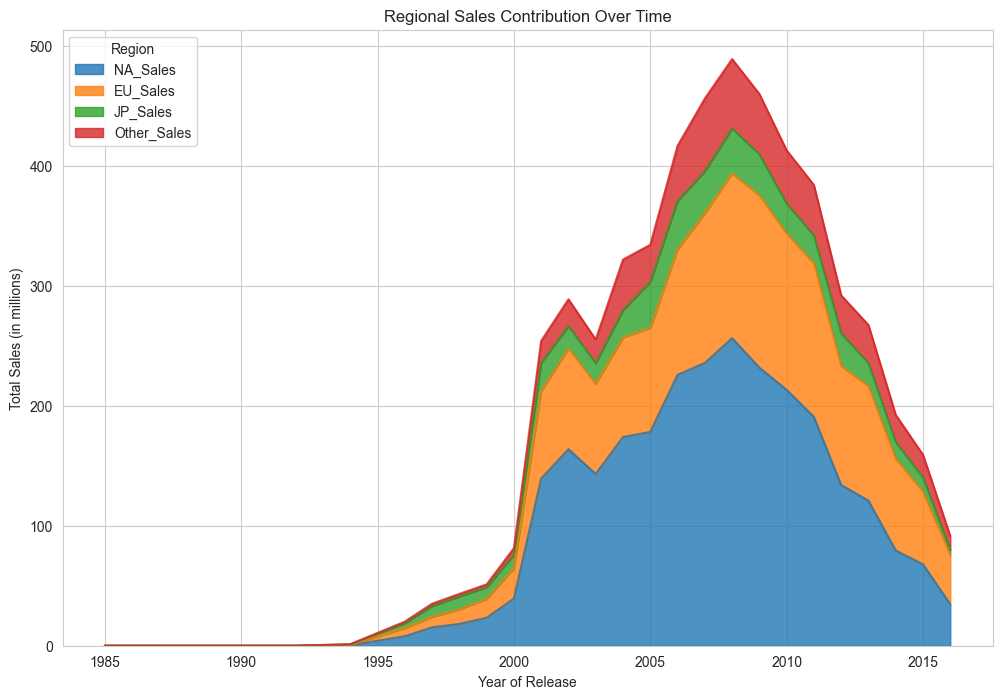

In [3]:
# Group data by year and sum regional sales
regional_sales_by_year = df.groupby('Year_of_Release')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

plt.figure(figsize=(12, 8))
regional_sales_by_year.plot(kind='area', stacked=True, alpha=0.8, figsize=(12, 8))
plt.title('Regional Sales Contribution Over Time')
plt.xlabel('Year of Release')
plt.ylabel('Total Sales (in millions)')
plt.legend(title='Region', loc='upper left')
plt.show()

c:\anaconda\envs\my_project_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\anaconda\envs\my_project_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 7.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\anaconda\envs\my_project_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 12.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


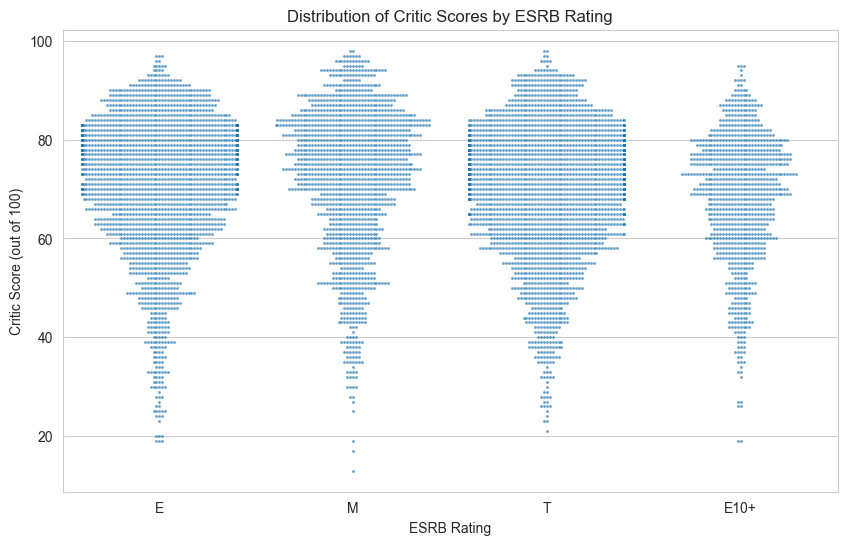

In [10]:
# Filter for the most common ratings
main_ratings = ['E', 'T', 'M', 'E10+'] 
df_ratings = df[df['Rating'].isin(main_ratings)]

plt.figure(figsize=(10, 6))
# Swarm plot to see the individual data points (scores) for each rating
sns.swarmplot(x='Rating', y='Critic_Score', data=df_ratings, size=2, alpha=0.7)
plt.title('Distribution of Critic Scores by ESRB Rating')
plt.xlabel('ESRB Rating')
plt.ylabel('Critic Score (out of 100)')
plt.show()

C:\Users\lulu\AppData\Local\Temp\ipykernel_29724\3002808644.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_genres['Global_Sales_Log'] = np.log1p(df_top_genres['Global_Sales'])
c:\anaconda\envs\my_project_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\anaconda\envs\my_project_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 32.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\anaconda\envs\my_project_env\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 14.1% of the p

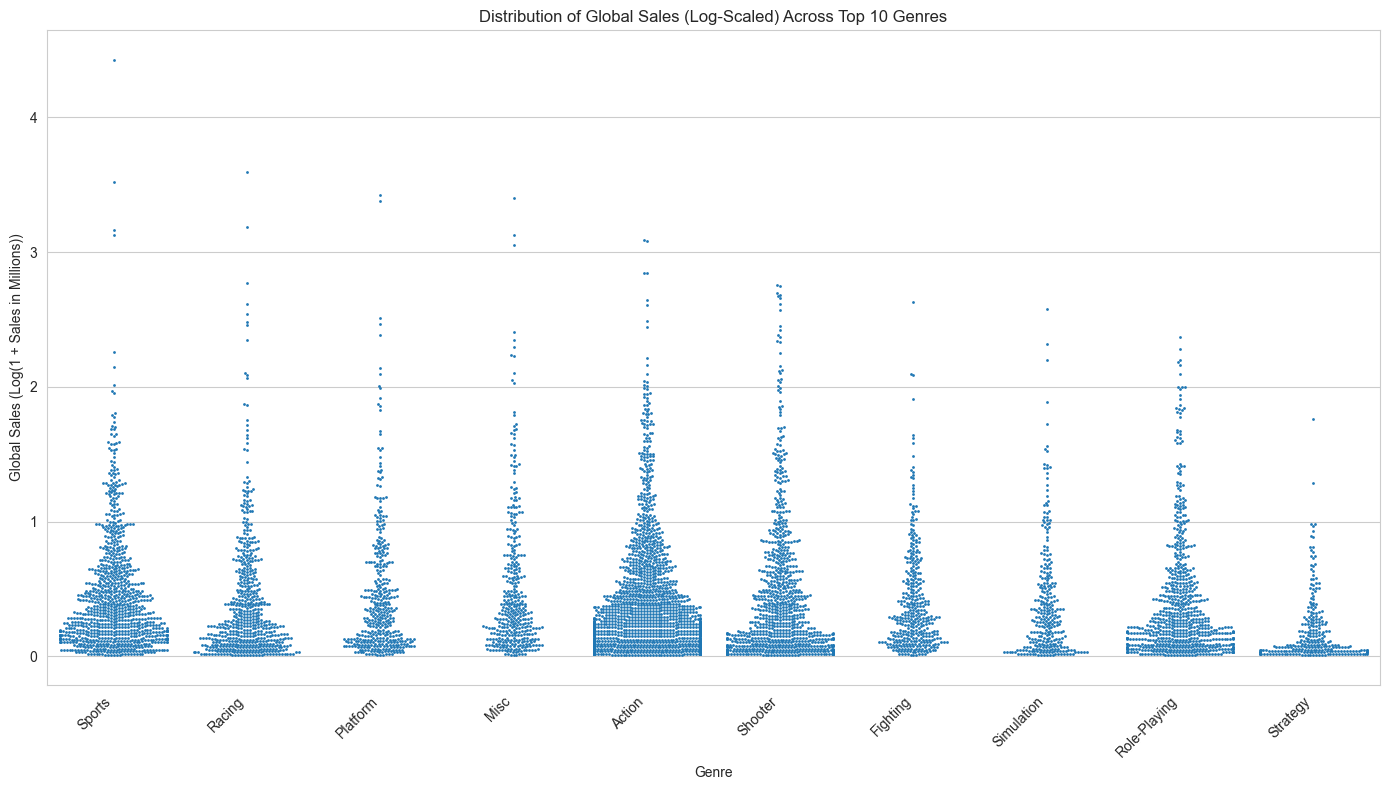

In [9]:
# Get the top 10 genres by game count
top_genres = df['Genre'].value_counts().nlargest(10).index
df_top_genres = df[df['Genre'].isin(top_genres)]

# Apply log transformation to Global_Sales for better visualization
df_top_genres['Global_Sales_Log'] = np.log1p(df_top_genres['Global_Sales'])

plt.figure(figsize=(14, 8))
sns.swarmplot(x='Genre', y='Global_Sales_Log', data=df_top_genres, size=2)
plt.title('Distribution of Global Sales (Log-Scaled) Across Top 10 Genres')
plt.xlabel('Genre')
plt.ylabel('Global Sales (Log(1 + Sales in Millions))')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

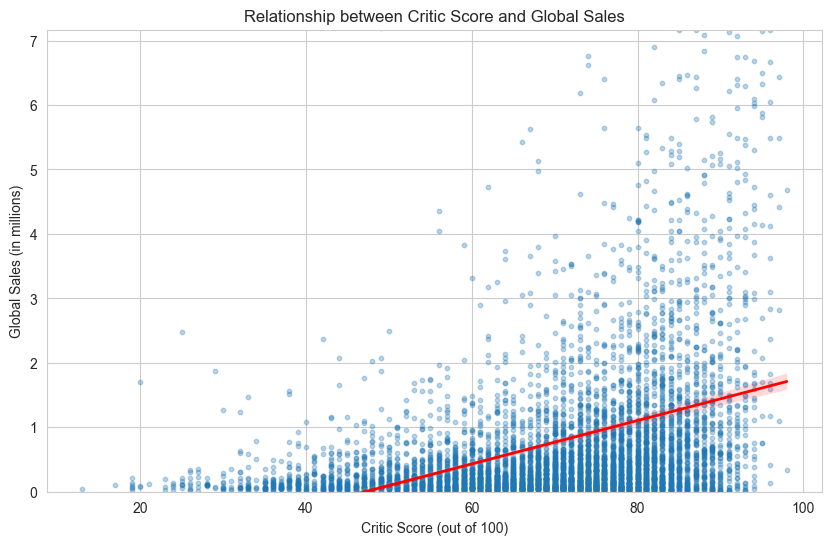

In [6]:
plt.figure(figsize=(10, 6))
# Regplot combines a scatter plot with a linear regression fit
sns.regplot(x='Critic_Score', y='Global_Sales', data=df, 
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red', 'linewidth':2})
plt.title('Relationship between Critic Score and Global Sales')
plt.xlabel('Critic Score (out of 100)')
plt.ylabel('Global Sales (in millions)')
plt.ylim(0, df['Global_Sales'].quantile(0.99)) # Limit Y-axis to 99th percentile for better focus
plt.show()

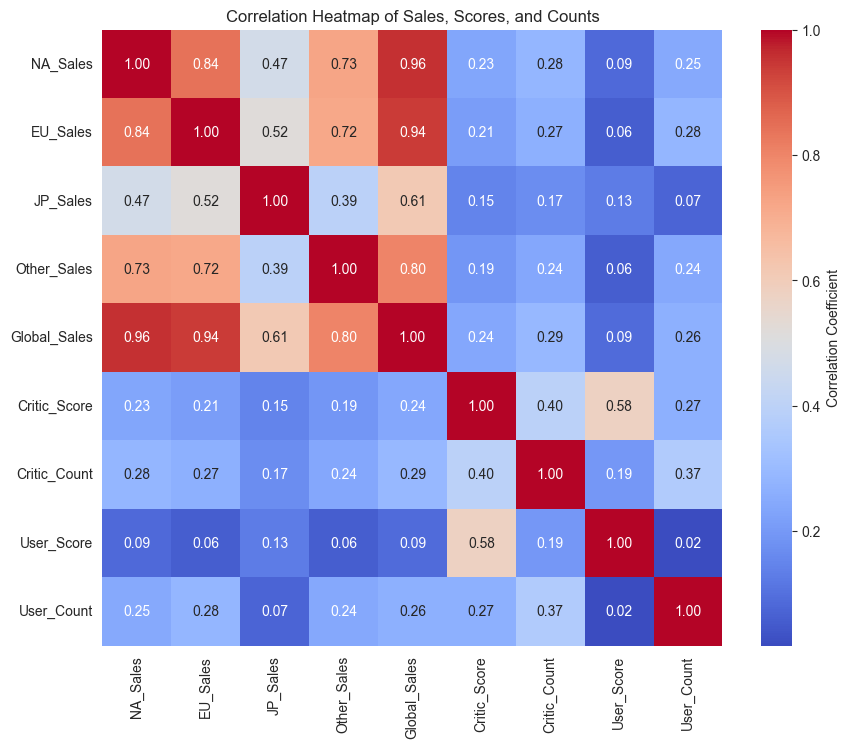

In [7]:
# Select the numeric columns of interest
corr_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 
             'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
# Use the heatmap to visualize the correlation matrix
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap of Sales, Scores, and Counts')
plt.show()

# Key takeaways from the heatmap:
# 1. Notice the high correlation between Global_Sales and NA_Sales/EU_Sales.
# 2. See which count/score variable has the strongest relationship with Global_Sales.

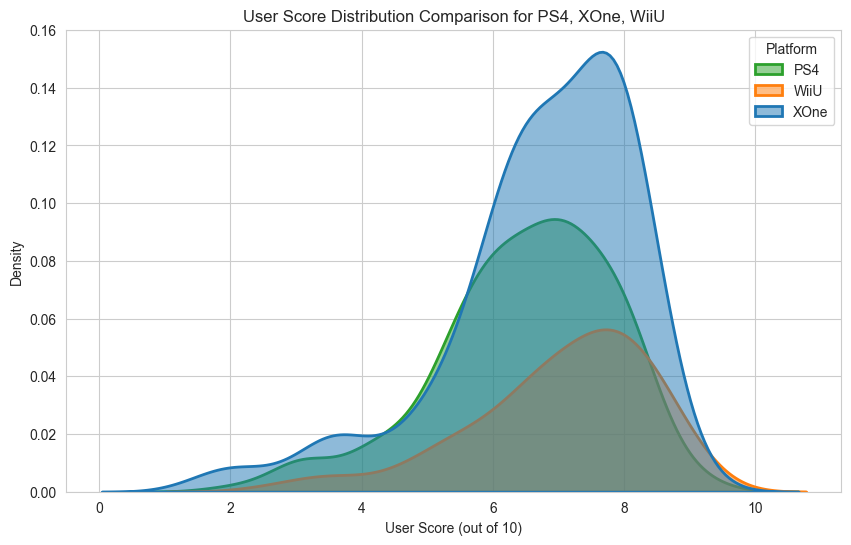

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data (assuming it's loaded as 'df')
# df = pd.read_csv('cleaned_video_games_data.csv') 

# --- Data Preparation ---
# Select two or three interesting platforms for comparison
selected_platforms = ['PS4', 'XOne', 'WiiU'] 
df_platforms = df[df['Platform'].isin(selected_platforms)]

# --- KDE Plot Visualization ---
plt.figure(figsize=(10, 6))

# Create the plot and capture the Axes object
ax = sns.kdeplot(
    data=df_platforms, 
    x='User_Score', 
    hue='Platform', 
    fill=True, 
    alpha=.5, 
    linewidth=2
)

plt.title(f'User Score Distribution Comparison for {", ".join(selected_platforms)}')
plt.xlabel('User Score (out of 10)')
plt.ylabel('Density')

# FIX: Get unique platform names for the legend
platform_names = df_platforms['Platform'].unique()
ax.legend(title='Platform', labels=platform_names)

plt.show()

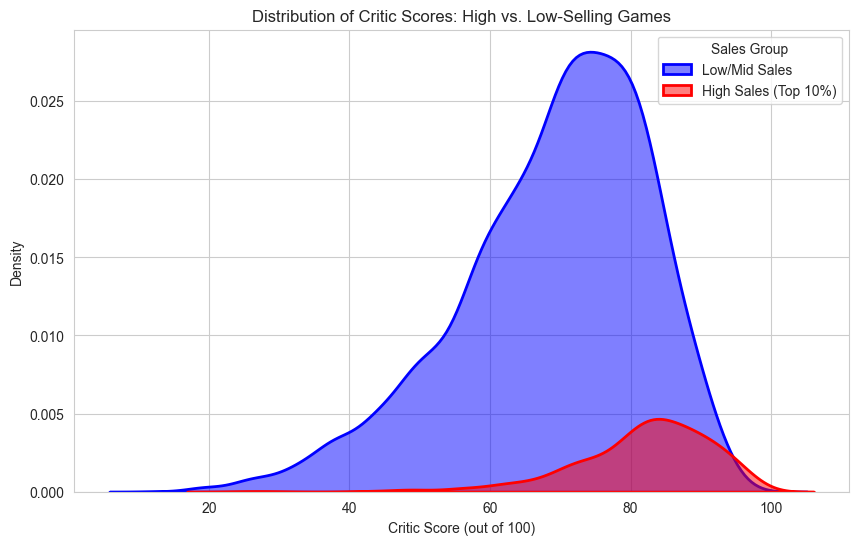

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data (assuming it's loaded as 'df')
# df = pd.read_csv('cleaned_video_games_data.csv') 

# --- Data Preparation ---
# Define the threshold for 'High Sales' (e.g., top 10% of Global Sales)
sales_threshold = df['Global_Sales'].quantile(0.90)

# Create a new categorical column
df['Sales_Performance'] = np.where(
    df['Global_Sales'] >= sales_threshold, 
    'High Sales (Top 10%)', 
    'Low/Mid Sales'
)

# --- KDE Plot Visualization ---
plt.figure(figsize=(10, 6))
# Create the plot and capture the Axes object
ax = sns.kdeplot(
    data=df, 
    x='Critic_Score', 
    hue='Sales_Performance', 
    fill=True, 
    alpha=.5, 
    linewidth=2,
    palette=['red', 'blue']
)

plt.title('Distribution of Critic Scores: High vs. Low-Selling Games')
plt.xlabel('Critic Score (out of 100)')
plt.ylabel('Density')

# FIX: Ensure the legend is correctly displayed
ax.legend(title='Sales Group', labels=['Low/Mid Sales', 'High Sales (Top 10%)'])

plt.show()

<Figure size 1000x600 with 0 Axes>

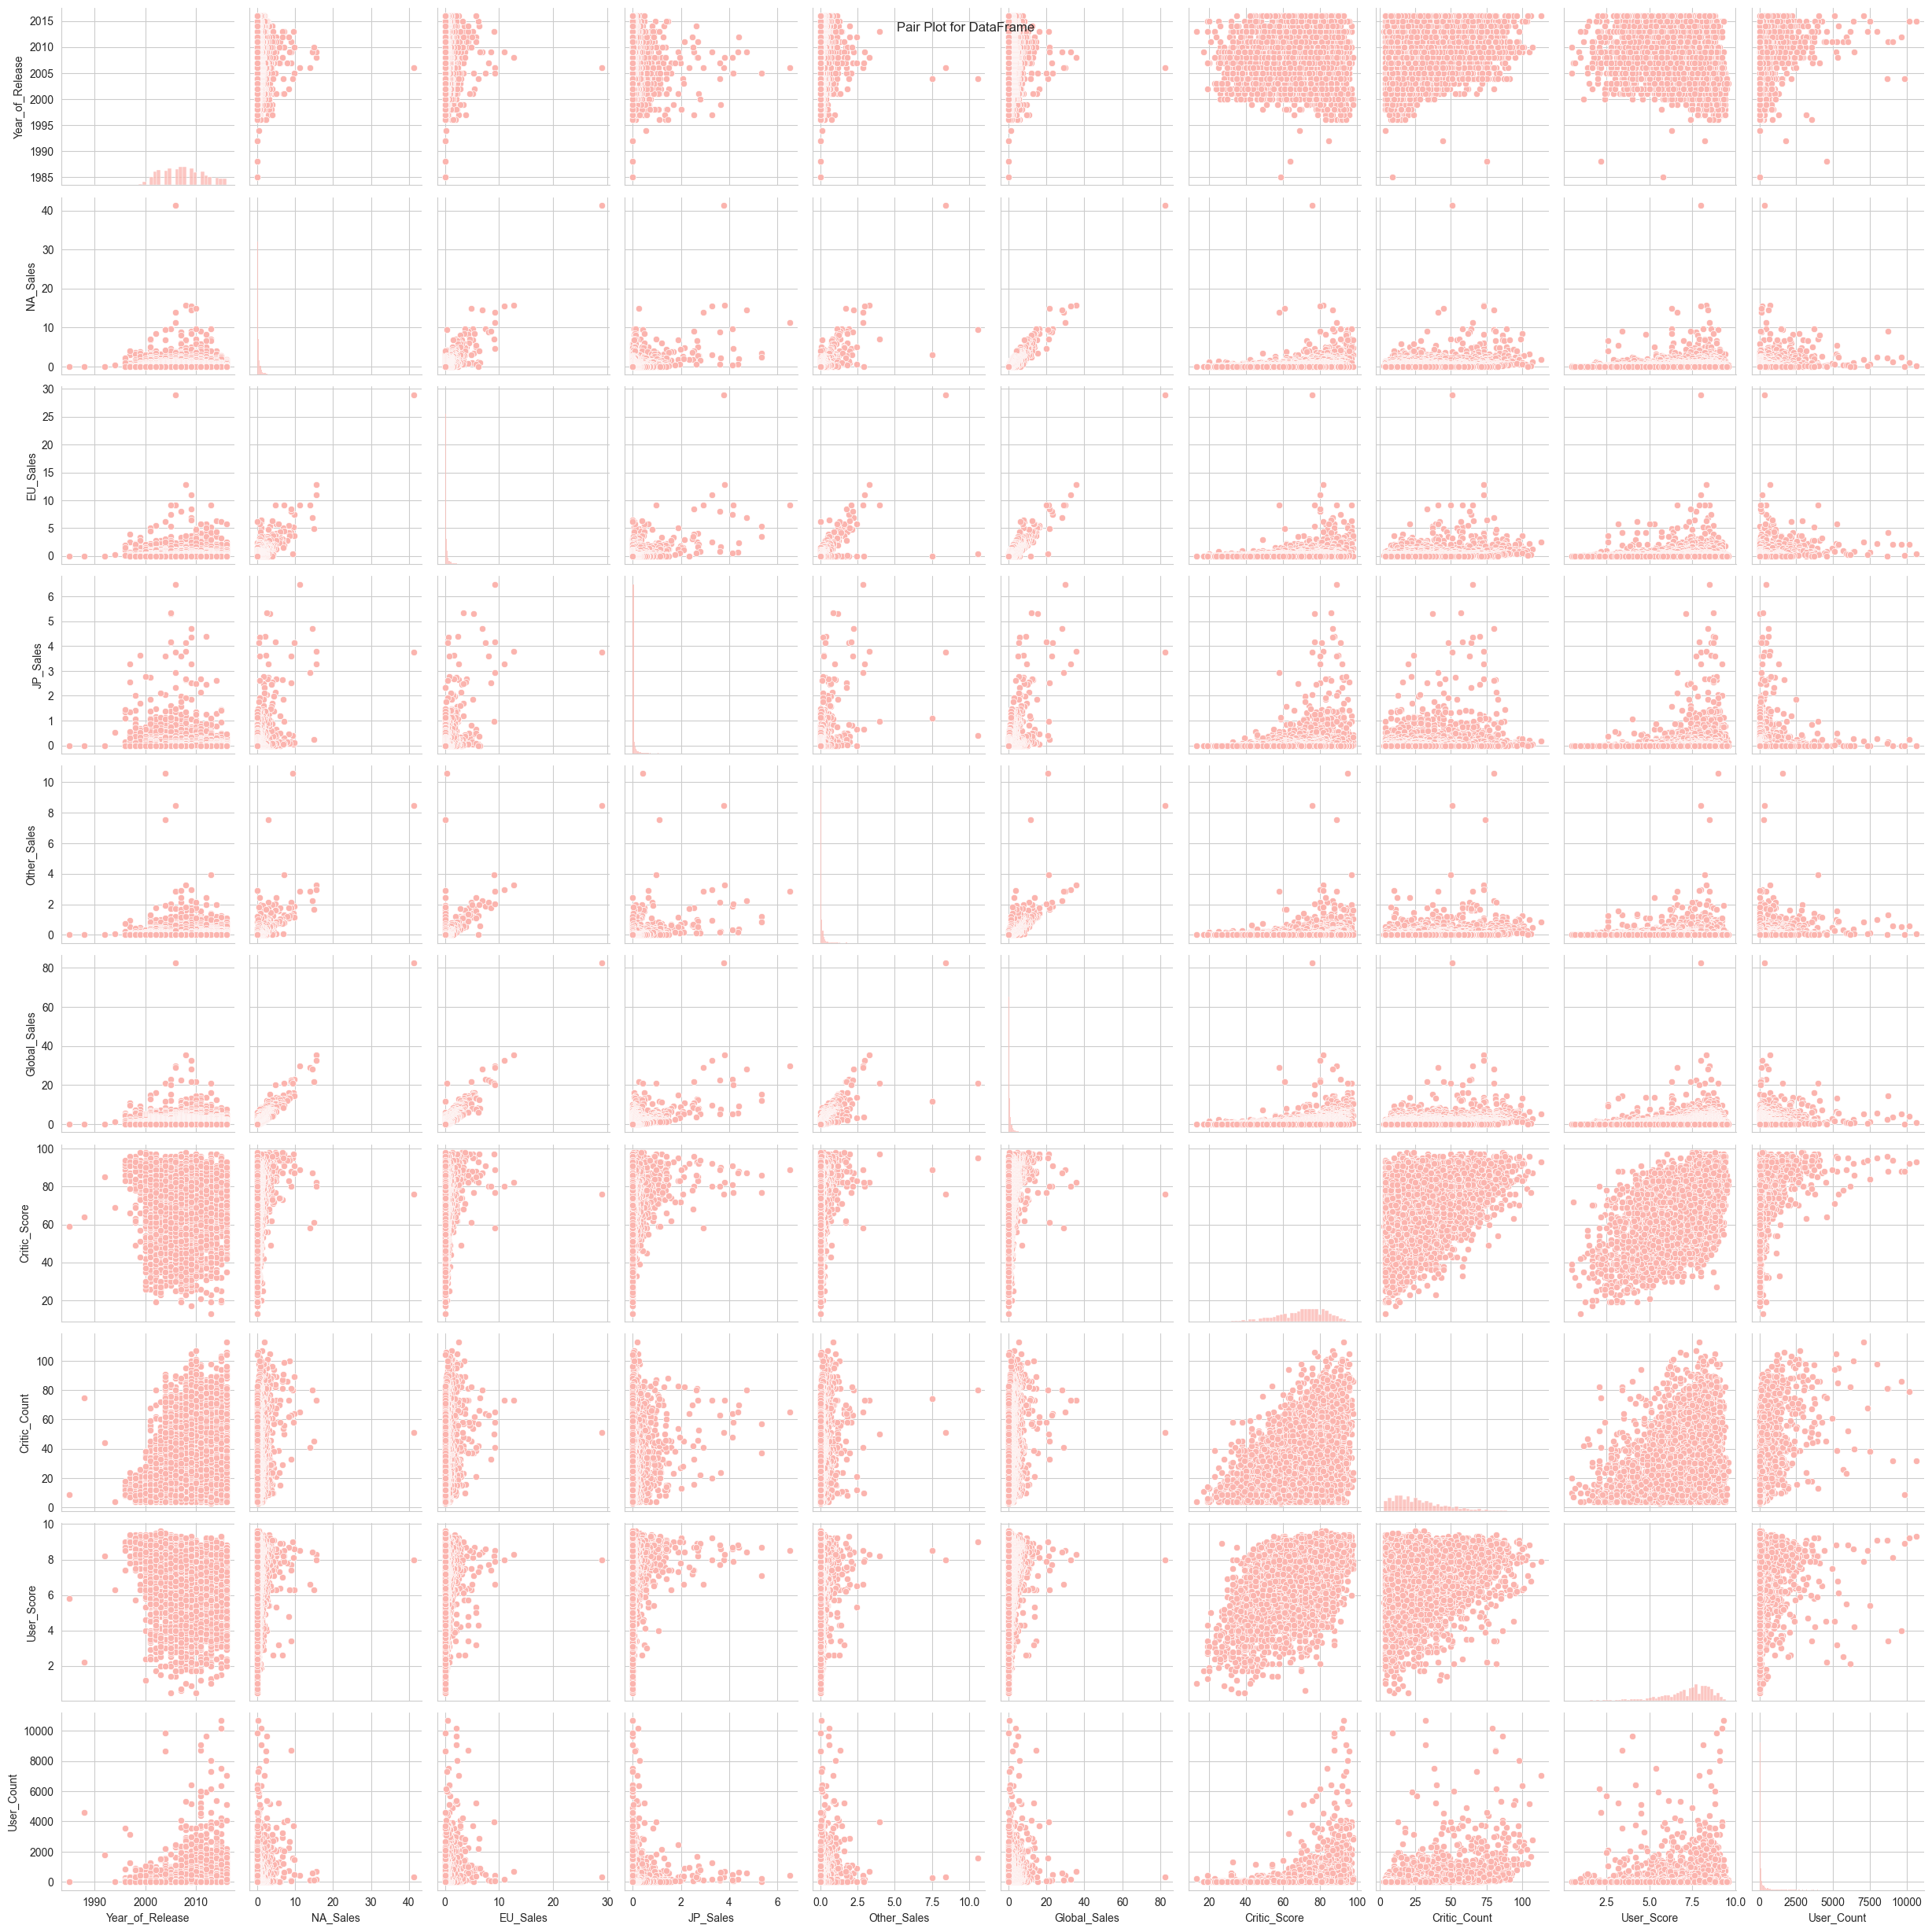

In [14]:
sns.set_palette("Pastel1")

plt.figure(figsize=(10, 6))

sns.pairplot(df)

plt.suptitle('Pair Plot for DataFrame')
plt.show()

## explain of the above graph
關係方向 (Direction):

正相關 (Positive Correlation): 點圖大致呈從左下到右上的趨勢（一個變量增加，另一個也增加）。
負相關 (Negative Correlation): 點圖大致呈從左上到右下的趨勢（一個變量增加，另一個減少）。
無關係 (No Correlation): 點圖呈現一團沒有明顯趨勢的雲狀分佈。

關係強度 (Strength):

強 (Strong): 點圖緊密地聚集在一個假想的直線上或曲線上。
弱 (Weak): 點圖分散，趨勢線不明顯。